<a href="https://colab.research.google.com/github/ahmednaoui23/BDD_Project/blob/main/MiniProjet_NAOUI_Ahmed_et_SOUDANA_Helmi_IA2_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Mini Projet : Detection et Segmentation de Fleurs
**Matiere :** Vision Artificielle et Traitement d'Images  
**Filiere :** 2eme annee Informatique Appliquee (IA-2.2)  
**Enseignante :** Mme Marwa Ghrouda  
**Annee Universitaire :** 2025/2026

In [ ]:
# Imports globaux
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# Upload de l'image
uploaded = files.upload()
image_path = list(uploaded.keys())[0]

print(f"Image chargee : {image_path}")

Saving flowers.png to flowers.png
Image chargee : flowers.png


---
## Etape 1 : Exploration et Analyse de l'Image

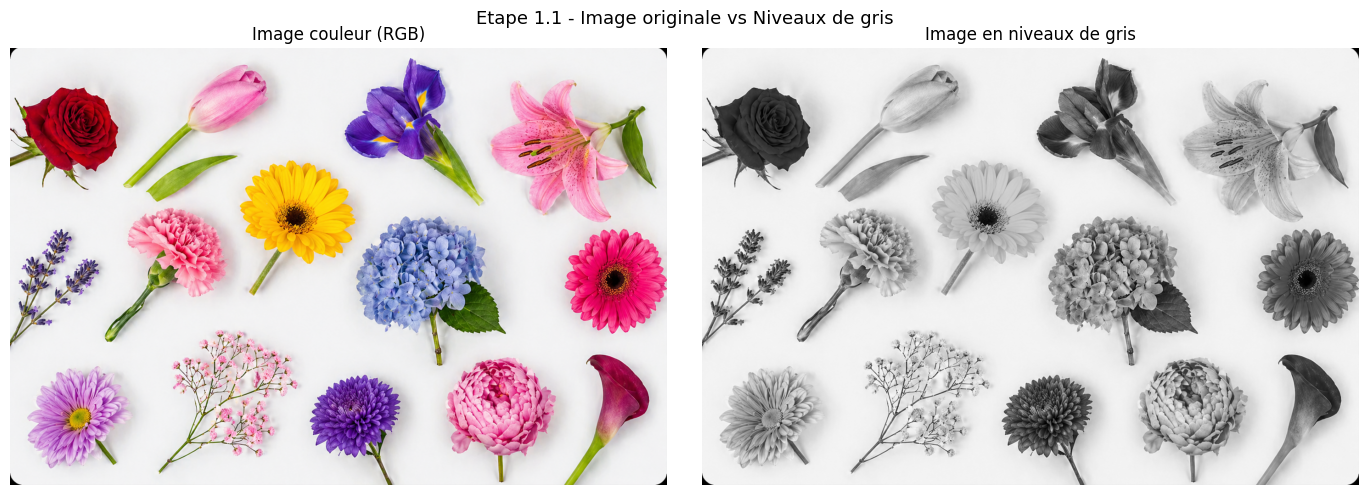

In [ ]:
# Chargement de l'image
img_bgr = cv2.imread(image_path)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

# 1. Affichage couleur et niveaux de gris
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(img_rgb)
axes[0].set_title('Image couleur (RGB)')
axes[0].axis('off')
axes[1].imshow(img_gray, cmap='gray')
axes[1].set_title('Image en niveaux de gris')
axes[1].axis('off')
plt.suptitle('Etape 1.1 - Image originale vs Niveaux de gris', fontsize=13)
plt.tight_layout()
plt.show()

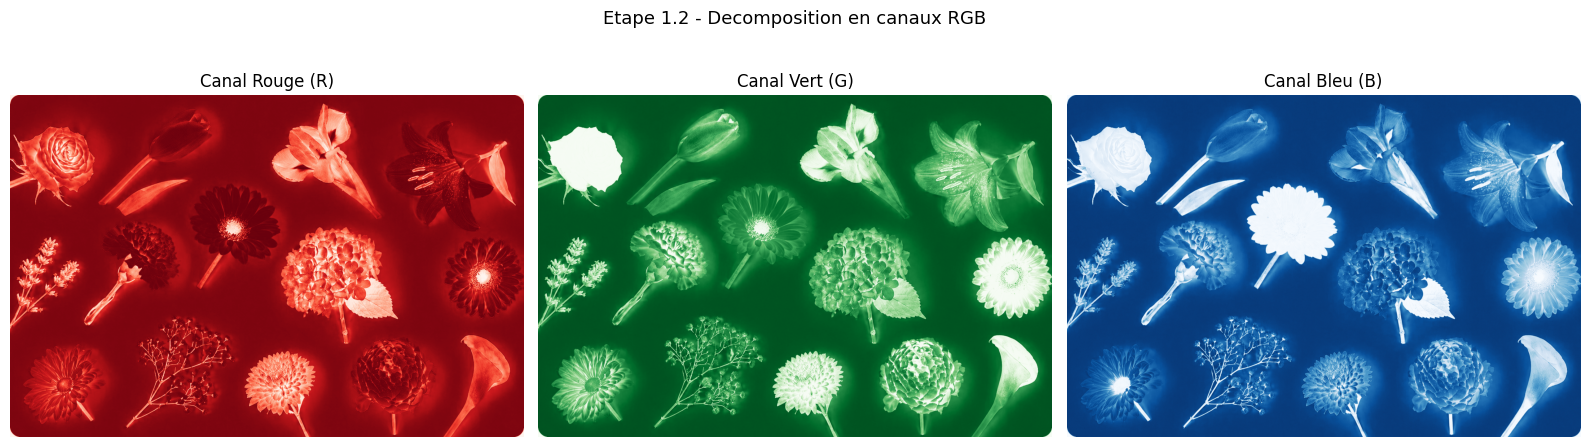

In [ ]:
# 2. Decomposition en canaux R, G, B
R, G, B = img_rgb[:,:,0], img_rgb[:,:,1], img_rgb[:,:,2]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
axes[0].imshow(R, cmap='Reds')
axes[0].set_title('Canal Rouge (R)')
axes[0].axis('off')
axes[1].imshow(G, cmap='Greens')
axes[1].set_title('Canal Vert (G)')
axes[1].axis('off')
axes[2].imshow(B, cmap='Blues')
axes[2].set_title('Canal Bleu (B)')
axes[2].axis('off')
plt.suptitle('Etape 1.2 - Decomposition en canaux RGB', fontsize=13)
plt.tight_layout()
plt.show()

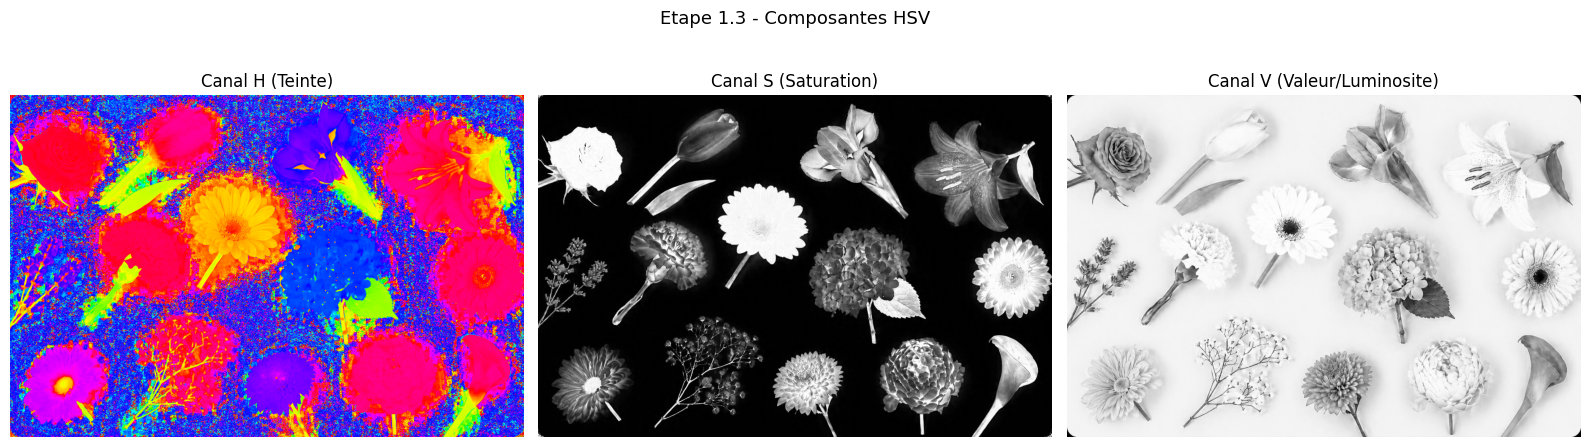

In [ ]:
# 3. Conversion en HSV et affichage des composantes H, S, V
img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
H, S, V = img_hsv[:,:,0], img_hsv[:,:,1], img_hsv[:,:,2]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
axes[0].imshow(H, cmap='hsv')
axes[0].set_title('Canal H (Teinte)')
axes[0].axis('off')
axes[1].imshow(S, cmap='gray')
axes[1].set_title('Canal S (Saturation)')
axes[1].axis('off')
axes[2].imshow(V, cmap='gray')
axes[2].set_title('Canal V (Valeur/Luminosite)')
axes[2].axis('off')
plt.suptitle('Etape 1.3 - Composantes HSV', fontsize=13)
plt.tight_layout()
plt.show()

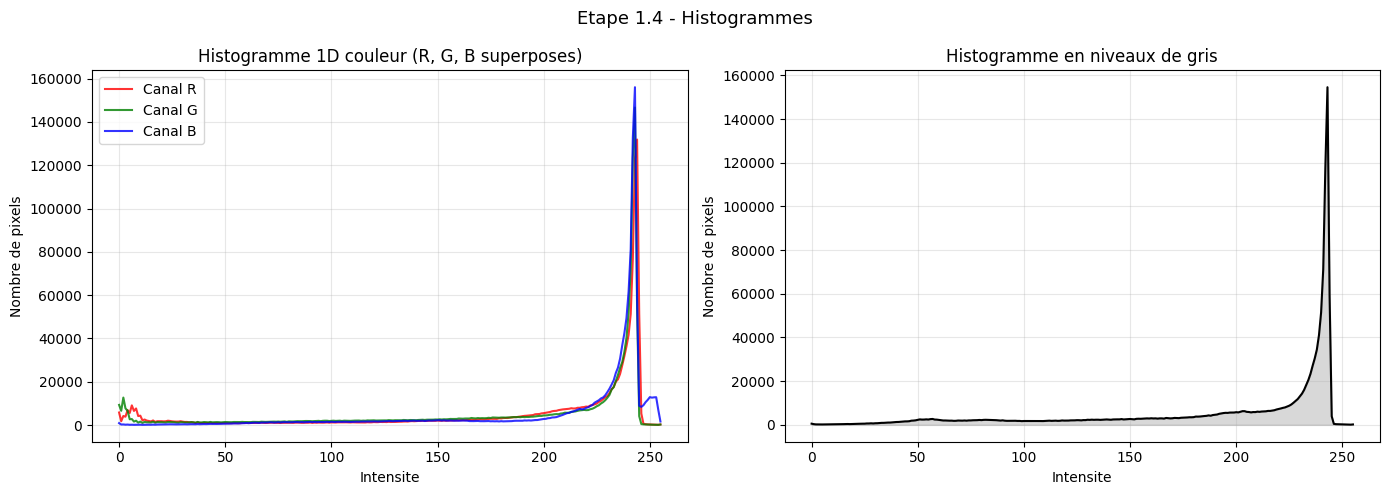

In [ ]:
# 4. Histogrammes couleur (R, G, B superposes) et niveaux de gris
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogramme couleur
colors = ('red', 'green', 'blue')
labels = ('Canal R', 'Canal G', 'Canal B')
for i, (color, label) in enumerate(zip(colors, labels)):
    hist = cv2.calcHist([img_bgr], [i], None, [256], [0, 256])
    axes[0].plot(hist, color=color, label=label, alpha=0.8)
axes[0].set_title('Histogramme 1D couleur (R, G, B superposes)')
axes[0].set_xlabel('Intensite')
axes[0].set_ylabel('Nombre de pixels')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Histogramme niveaux de gris
hist_gray = cv2.calcHist([img_gray], [0], None, [256], [0, 256])
axes[1].plot(hist_gray, color='black')
axes[1].fill_between(range(256), hist_gray.ravel(), alpha=0.3, color='gray')
axes[1].set_title('Histogramme en niveaux de gris')
axes[1].set_xlabel('Intensite')
axes[1].set_ylabel('Nombre de pixels')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Etape 1.4 - Histogrammes', fontsize=13)
plt.tight_layout()
plt.show()

### Reponse a la question - Etape 1

En observant le canal H (teinte) de l'image HSV, on peut identifier les plages correspondant aux differents types de fleurs :

- **Fleurs rouges (roses)** : H entre 0 et 10 (et eventuellement 160-180 pour les rouges fonces, car la teinte rouge se situe aux deux extremites de la plage HSV).
- **Fleurs jaunes (gerberas jaunes)** : H entre 20 et 35.
- **Fleurs violettes/lavande** : H entre 125 et 160.
- **Fleurs roses (tulipe, carnation, pivoine)** : H entre 140 et 175 avec une saturation moderee.
- **Fleurs bleues (iris, hortensia)** : H entre 100 et 130.
- **Tiges et feuilles vertes** : H entre 35 et 85.

Les tiges et feuilles se distinguent generalement bien des petales grace a leur canal H tres different (zone verte vs zones colorees des petales). Cependant, sur un fond blanc, le canal S (saturation) est tres faible pour le fond, ce qui permet de le separer des fleurs dont la saturation est elevee.

---
## Etape 2 : Amelioration de la Qualite

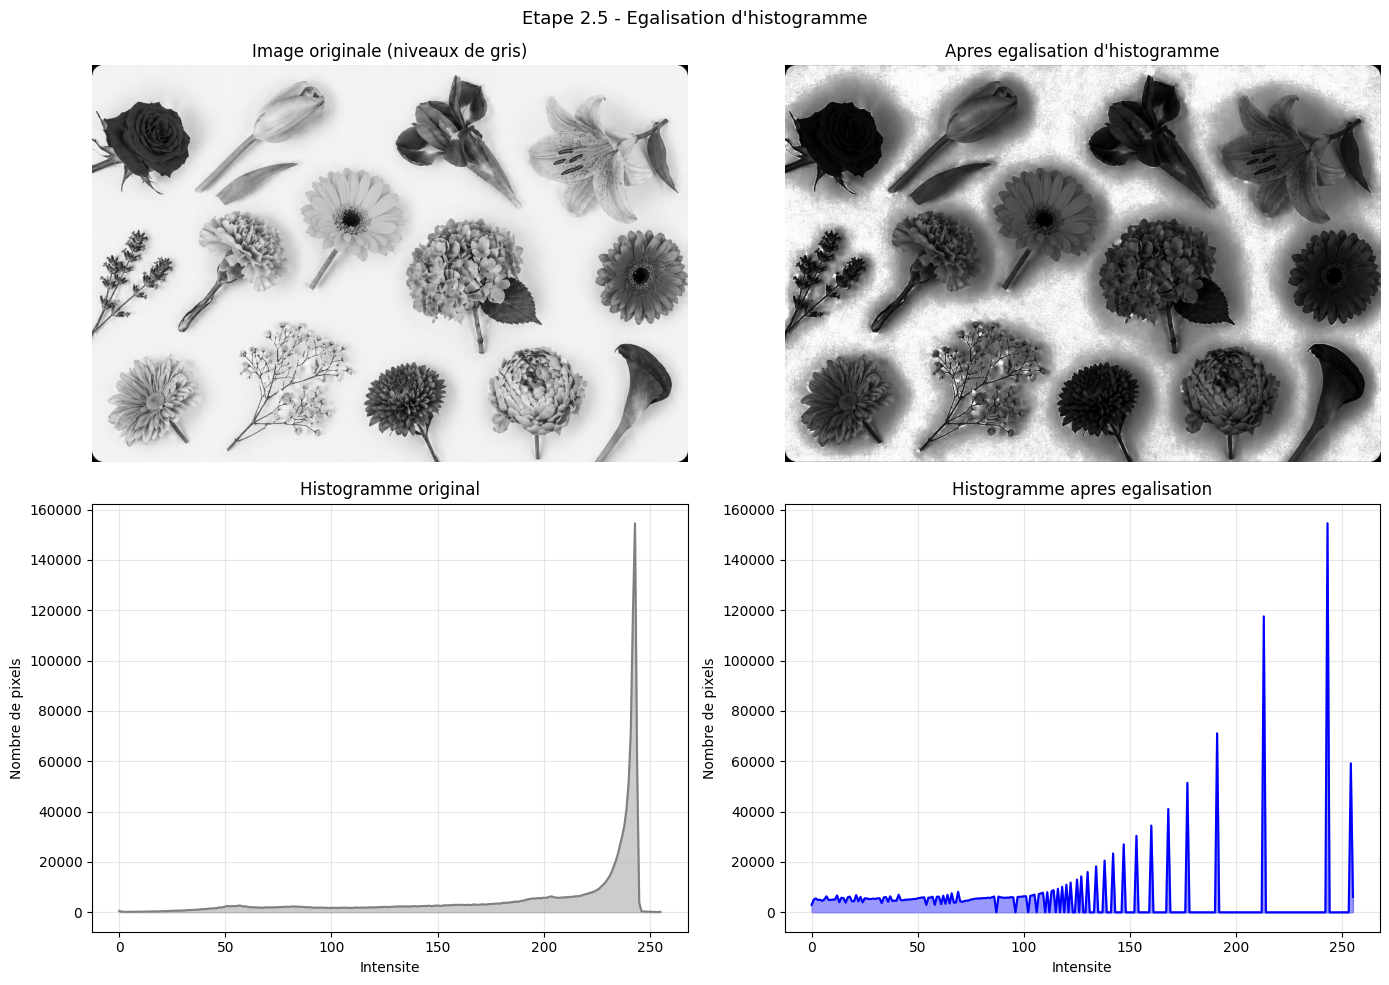

In [ ]:
# 5. Egalisation d'histogramme
img_eq = cv2.equalizeHist(img_gray)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].imshow(img_gray, cmap='gray')
axes[0, 0].set_title('Image originale (niveaux de gris)')
axes[0, 0].axis('off')

axes[0, 1].imshow(img_eq, cmap='gray')
axes[0, 1].set_title('Apres egalisation d\'histogramme')
axes[0, 1].axis('off')

hist_orig = cv2.calcHist([img_gray], [0], None, [256], [0, 256])
axes[1, 0].plot(hist_orig, color='gray')
axes[1, 0].fill_between(range(256), hist_orig.ravel(), alpha=0.4, color='gray')
axes[1, 0].set_title('Histogramme original')
axes[1, 0].set_xlabel('Intensite')
axes[1, 0].set_ylabel('Nombre de pixels')
axes[1, 0].grid(True, alpha=0.3)

hist_eq = cv2.calcHist([img_eq], [0], None, [256], [0, 256])
axes[1, 1].plot(hist_eq, color='blue')
axes[1, 1].fill_between(range(256), hist_eq.ravel(), alpha=0.4, color='blue')
axes[1, 1].set_title('Histogramme apres egalisation')
axes[1, 1].set_xlabel('Intensite')
axes[1, 1].set_ylabel('Nombre de pixels')
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle('Etape 2.5 - Egalisation d\'histogramme', fontsize=13)
plt.tight_layout()
plt.show()

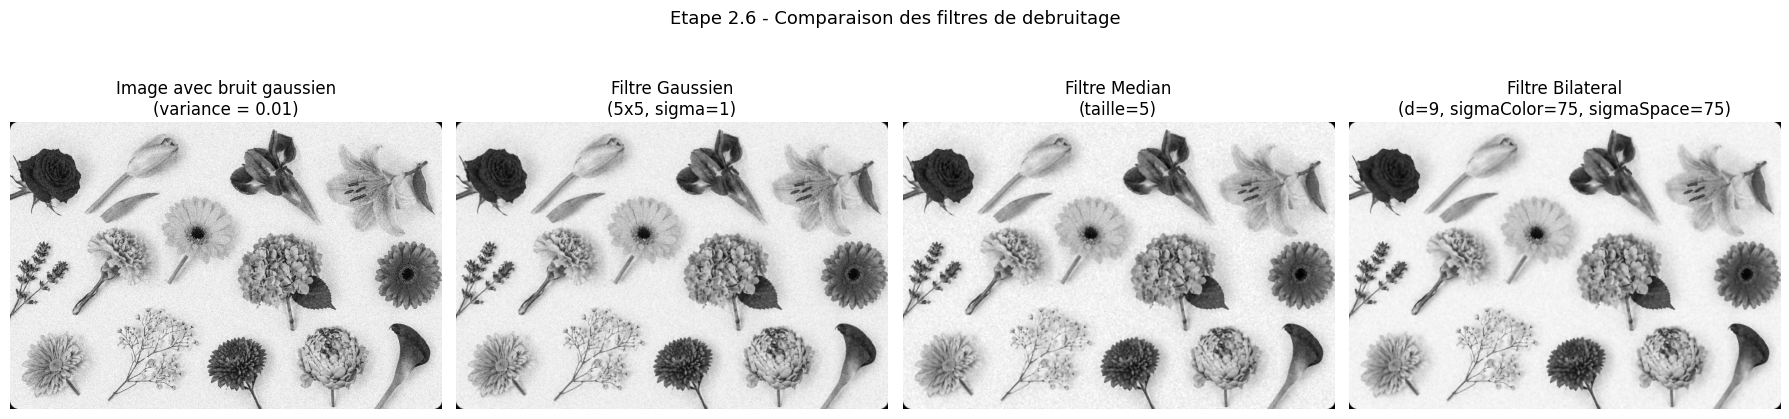

In [ ]:
# 6. Ajout de bruit gaussien et comparaison des filtres

# Ajout de bruit gaussien (variance = 0.01)
img_normalized = img_gray.astype(np.float64) / 255.0
noise = np.random.normal(0, np.sqrt(0.01), img_normalized.shape)
img_noisy = np.clip(img_normalized + noise, 0, 1)
img_noisy_uint8 = (img_noisy * 255).astype(np.uint8)

# Application des trois filtres
img_gaussian = cv2.GaussianBlur(img_noisy_uint8, (5, 5), 1)
img_median = cv2.medianBlur(img_noisy_uint8, 5)
img_bilateral = cv2.bilateralFilter(img_noisy_uint8, 9, 75, 75)

fig, axes = plt.subplots(1, 4, figsize=(18, 5))

axes[0].imshow(img_noisy_uint8, cmap='gray')
axes[0].set_title('Image avec bruit gaussien\n(variance = 0.01)')
axes[0].axis('off')

axes[1].imshow(img_gaussian, cmap='gray')
axes[1].set_title('Filtre Gaussien\n(5x5, sigma=1)')
axes[1].axis('off')

axes[2].imshow(img_median, cmap='gray')
axes[2].set_title('Filtre Median\n(taille=5)')
axes[2].axis('off')

axes[3].imshow(img_bilateral, cmap='gray')
axes[3].set_title('Filtre Bilateral\n(d=9, sigmaColor=75, sigmaSpace=75)')
axes[3].axis('off')

plt.suptitle('Etape 2.6 - Comparaison des filtres de debruitage', fontsize=13)
plt.tight_layout()
plt.show()

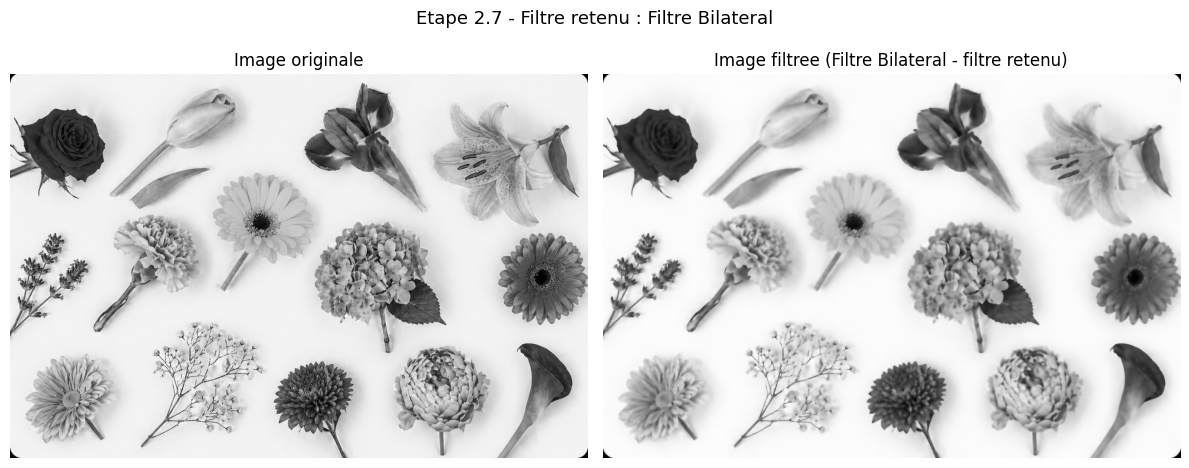

Filtre retenu : Filtre Bilateral


In [ ]:
# 7. Filtre retenu pour la suite du pipeline
# Le filtre bilateral est retenu
img_filtered = cv2.bilateralFilter(img_gray, 9, 75, 75)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(img_gray, cmap='gray')
axes[0].set_title('Image originale')
axes[0].axis('off')
axes[1].imshow(img_filtered, cmap='gray')
axes[1].set_title('Image filtree (Filtre Bilateral - filtre retenu)')
axes[1].axis('off')

plt.suptitle('Etape 2.7 - Filtre retenu : Filtre Bilateral', fontsize=13)
plt.tight_layout()
plt.show()

print("Filtre retenu : Filtre Bilateral")

### Reponse a la question - Etape 2

**Choix du filtre : Filtre Bilateral**

Le filtre bilateral est particulierement adapte aux images de fleurs aux petales fins pour les raisons suivantes :

- **Preservation des contours** : contrairement au filtre gaussien qui lisse de maniere uniforme (y compris les bords des petales), le filtre bilateral applique un lissage selectif. Il tient compte a la fois de la proximite spatiale et de la similarite d'intensite des pixels. Ainsi, les transitions nettes entre un petale et le fond ou entre deux petales adjacents sont preservees.
- **Reduction du bruit a l'interieur des zones uniformes** : les zones de couleur homogene a l'interieur des petales sont bien lissees, ce qui supprime le bruit gaussien sans degrader les bordures.
- **Effet sur les frontieres** : le filtre bilateral maintient des frontieres nettes entre un petale et le fond blanc, ce qui est essentiel pour la detection de contours precise a l'etape suivante. Le filtre gaussien produirait un flou a ces frontieres, degradant la qualite de la detection Canny ou Sobel.

Le filtre median est efficace contre le bruit impulsionnel (sel et poivre) mais moins optimal ici car notre bruit est gaussien. Le filtre bilateral reste le meilleur compromis bruit / preservation des contours pour ce type d'image.

---
## Etape 3 : Detection des Contours des Fleurs

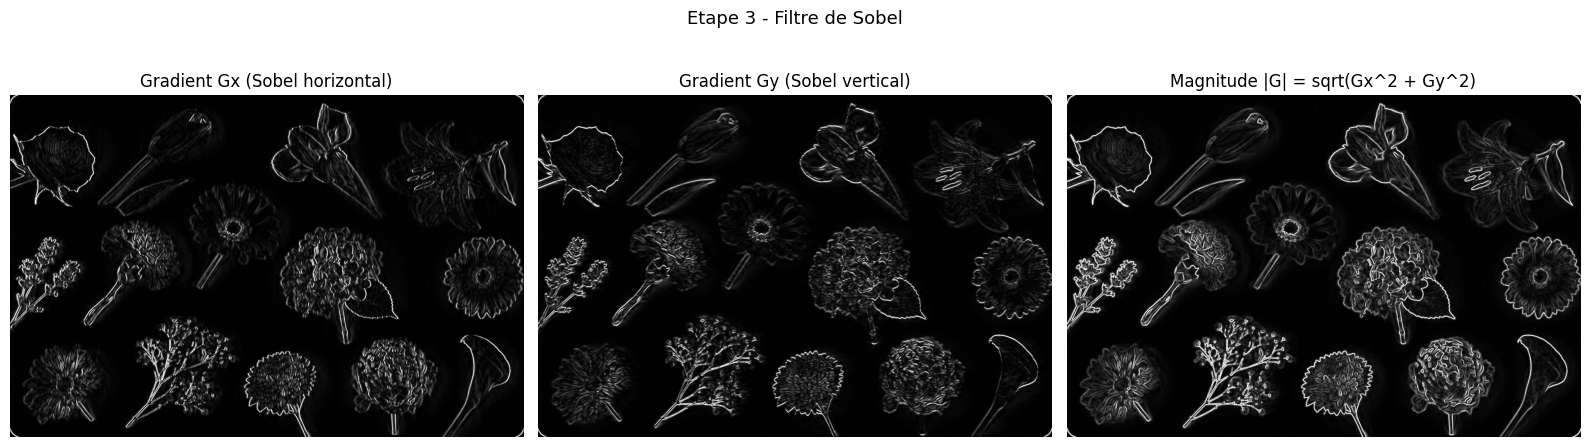

In [ ]:
# Filtre de Sobel - calcul de Gx, Gy et magnitude
sobel_x = cv2.Sobel(img_filtered, cv2.CV_64F, 1, 0, ksize=3)
sobel_y = cv2.Sobel(img_filtered, cv2.CV_64F, 0, 1, ksize=3)
sobel_mag = np.sqrt(sobel_x**2 + sobel_y**2)

# Normalisation pour affichage
sobel_x_disp = cv2.convertScaleAbs(sobel_x)
sobel_y_disp = cv2.convertScaleAbs(sobel_y)
sobel_mag_disp = cv2.convertScaleAbs(sobel_mag)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
axes[0].imshow(sobel_x_disp, cmap='gray')
axes[0].set_title('Gradient Gx (Sobel horizontal)')
axes[0].axis('off')
axes[1].imshow(sobel_y_disp, cmap='gray')
axes[1].set_title('Gradient Gy (Sobel vertical)')
axes[1].axis('off')
axes[2].imshow(sobel_mag_disp, cmap='gray')
axes[2].set_title('Magnitude |G| = sqrt(Gx^2 + Gy^2)')
axes[2].axis('off')

plt.suptitle('Etape 3 - Filtre de Sobel', fontsize=13)
plt.tight_layout()
plt.show()

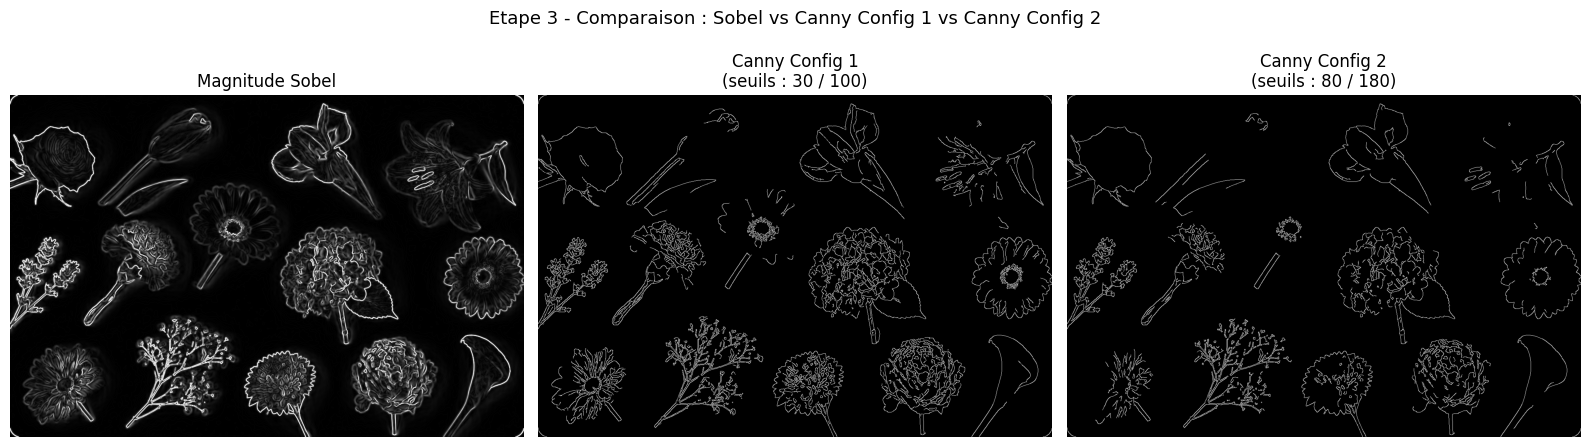

In [ ]:
# 8 & 9. Filtre de Canny - deux configurations
canny_config1 = cv2.Canny(img_filtered, 30, 100)
canny_config2 = cv2.Canny(img_filtered, 80, 180)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
axes[0].imshow(sobel_mag_disp, cmap='gray')
axes[0].set_title('Magnitude Sobel')
axes[0].axis('off')
axes[1].imshow(canny_config1, cmap='gray')
axes[1].set_title('Canny Config 1\n(seuils : 30 / 100)')
axes[1].axis('off')
axes[2].imshow(canny_config2, cmap='gray')
axes[2].set_title('Canny Config 2\n(seuils : 80 / 180)')
axes[2].axis('off')

plt.suptitle('Etape 3 - Comparaison : Sobel vs Canny Config 1 vs Canny Config 2', fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
# 10. Choix de la configuration Canny pour la suite
# On retient la configuration 2 (seuils 80/180) pour des contours plus nets et moins de bruit
canny_final = canny_config2.copy()

print("Configuration Canny retenue : Config 2 (seuils 80 / 180)")

Configuration Canny retenue : Config 2 (seuils 80 / 180)


### Reponse a la question - Etape 3

**Analyse des contours detectes :**

Les contours detectes correspondent globalement aux bords des petales et des tiges. La configuration Canny 2 (seuils 80/180) est retenue car :
- Elle produit des contours plus significatifs et continus sur les bords exterieurs des fleurs.
- Elle supprime davantage de contours parasites par rapport a la config 1 (seuils 30/100) qui detecte trop de details a l'interieur des petales (nervures, reflets lumineux, variations de texture).

**Contours parasites :**
Oui, des contours parasites apparaissent a l'interieur des petales, notamment :
- Les nervures des petales (variations de texture fine).
- Les reflets lumineux sur les surfaces brillantes.
- Les zones d'ombre et de transition de couleur a l'interieur d'une meme fleur.

**Comment les minimiser :**
- Augmenter les seuils de Canny reduit les contours parasites mais risque de perdre des bords importants.
- Appliquer un flou bilateral plus fort avant la detection lisse les textures internes.
- Utiliser une operation morphologique de fermeture (dilatation puis erosion) apres la detection Canny pour combler les discontinuites et supprimer les petits contours isoles.

---
## Etape 4 : Segmentation de Chaque Fleur par Couleur

In [ ]:
# 11. Conversion en HSV (deja fait a l'etape 1)
# img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)  # deja disponible

# 12 & 13. Definition des plages HSV et creation des masques
# Ajustement des plages selon l'image de travail

flowers = {
    'Rose rouge': {
        'lower': np.array([0, 80, 80]),
        'upper': np.array([10, 255, 255]),
        'lower2': np.array([160, 80, 80]),
        'upper2': np.array([180, 255, 255]),
        'color_box': (0, 0, 200)   # BGR
    },
    'Gerbera jaune': {
        'lower': np.array([20, 80, 80]),
        'upper': np.array([35, 255, 255]),
        'color_box': (0, 200, 200)
    },
    'Lavande / fleur violette': {
        'lower': np.array([125, 50, 50]),
        'upper': np.array([160, 255, 255]),
        'color_box': (180, 0, 180)
    },
    'Tiges et feuilles vertes': {
        'lower': np.array([35, 50, 50]),
        'upper': np.array([85, 255, 255]),
        'color_box': (0, 180, 0)
    },
    'Fleurs roses': {
        'lower': np.array([140, 40, 100]),
        'upper': np.array([175, 255, 255]),
        'color_box': (180, 50, 230)
    },
    'Fleur bleue / iris': {
        'lower': np.array([100, 60, 50]),
        'upper': np.array([130, 255, 255]),
        'color_box': (200, 100, 0)
    },
}

print("Plages HSV definies pour", len(flowers), "types de fleurs.")

Plages HSV definies pour 6 types de fleurs.


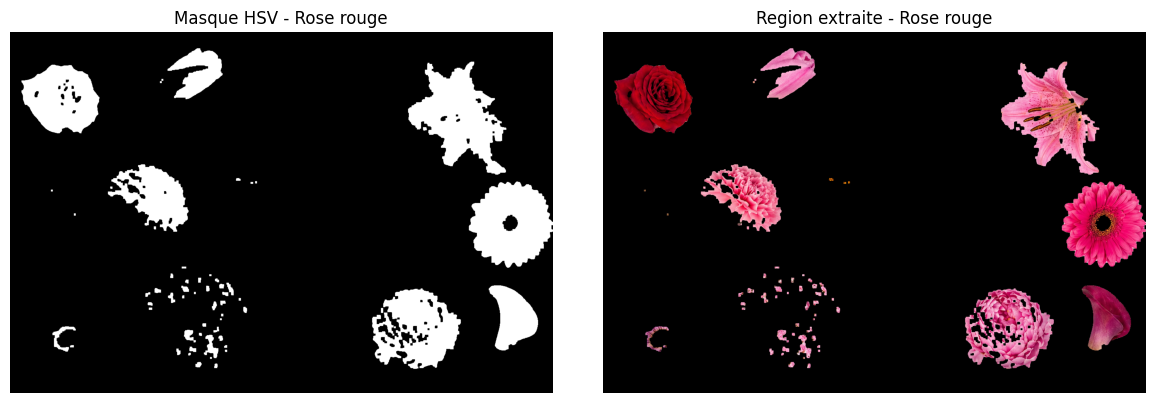

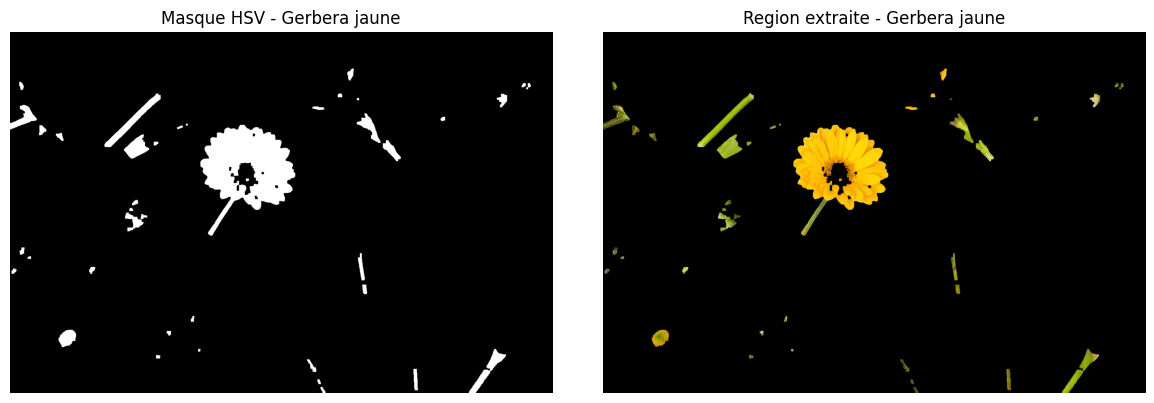

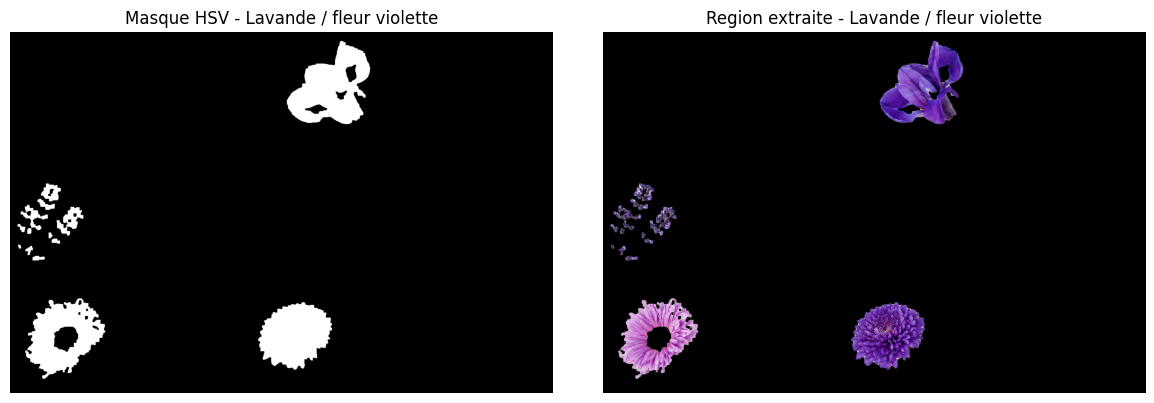

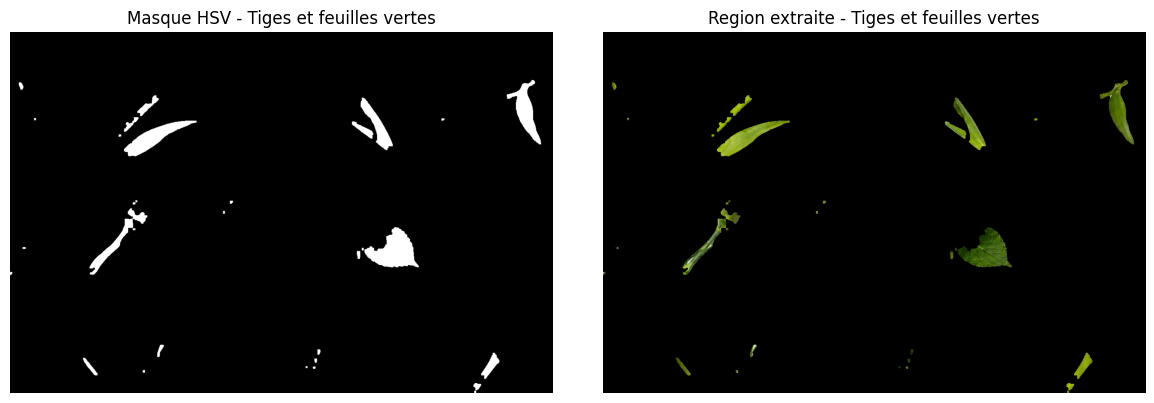

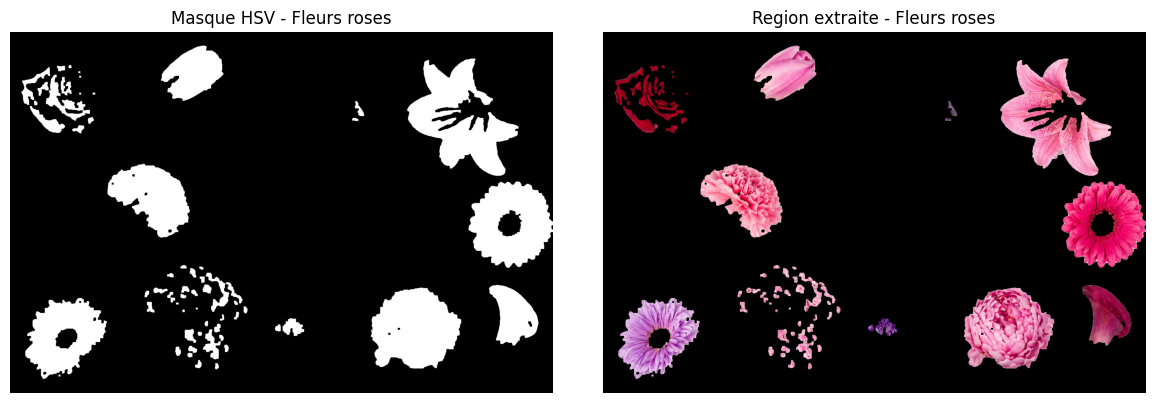

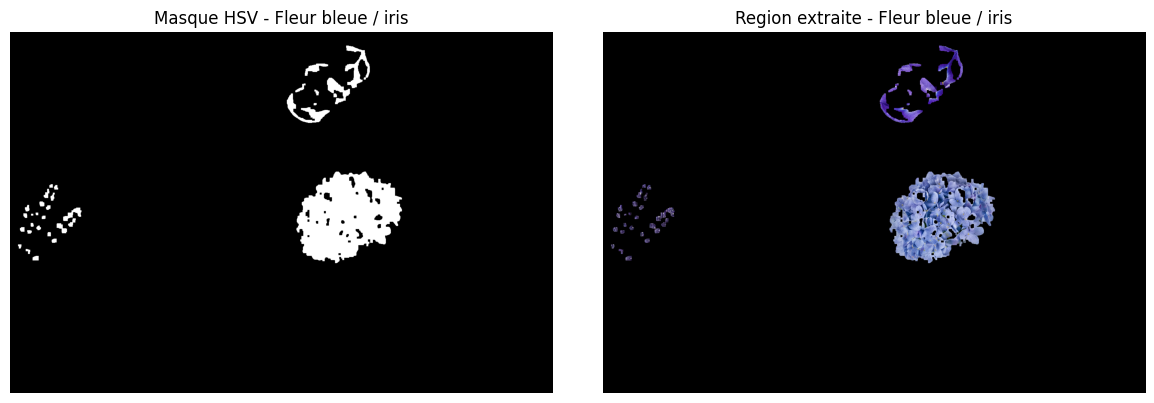

In [ ]:
# 13 & 14. Application des masques et affichage
masques = {}

for nom, params in flowers.items():
    lower = params['lower']
    upper = params['upper']
    mask = cv2.inRange(img_hsv, lower, upper)

    # Pour les roses rouges : union de deux plages (rouge aux deux extremites de H)
    if 'lower2' in params:
        mask2 = cv2.inRange(img_hsv, params['lower2'], params['upper2'])
        mask = cv2.bitwise_or(mask, mask2)

    # Nettoyage morphologique du masque
    kernel = np.ones((5, 5), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)

    masques[nom] = mask

    # Application du masque sur l'image originale
    region = cv2.bitwise_and(img_rgb, img_rgb, mask=mask)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].imshow(mask, cmap='gray')
    axes[0].set_title(f'Masque HSV - {nom}')
    axes[0].axis('off')
    axes[1].imshow(region)
    axes[1].set_title(f'Region extraite - {nom}')
    axes[1].axis('off')
    plt.tight_layout()
    plt.show()

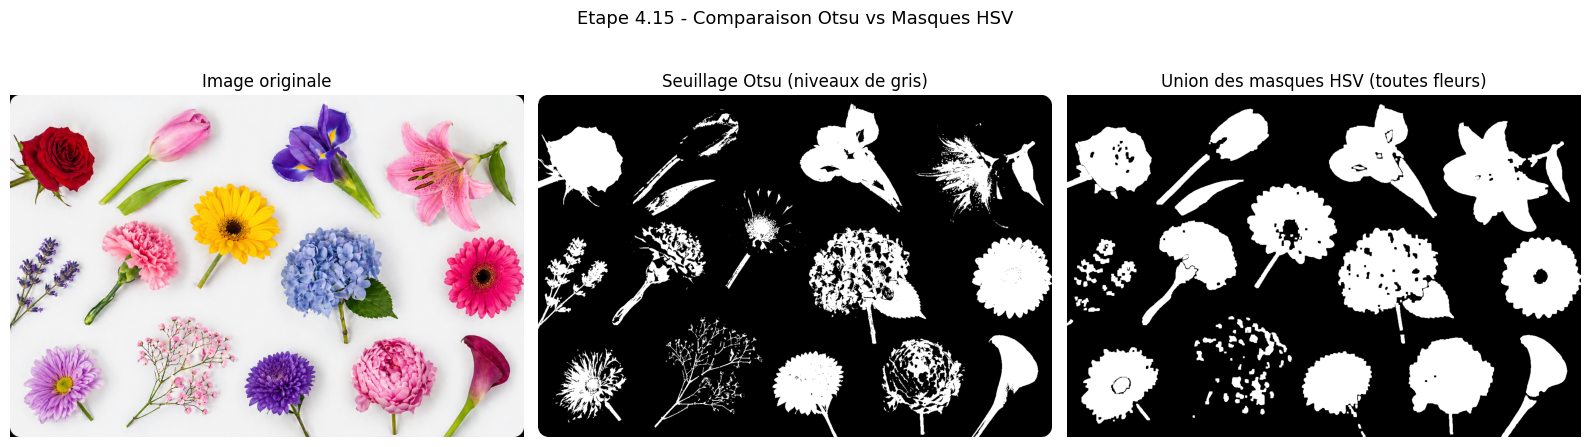

In [ ]:
# 15. Methode d'Otsu et comparaison avec les masques HSV
_, otsu_mask = cv2.threshold(img_gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
axes[0].imshow(img_rgb)
axes[0].set_title('Image originale')
axes[0].axis('off')
axes[1].imshow(otsu_mask, cmap='gray')
axes[1].set_title('Seuillage Otsu (niveaux de gris)')
axes[1].axis('off')
# Masque HSV global (union de tous les masques de fleurs sauf tiges)
mask_global = np.zeros(img_gray.shape, dtype=np.uint8)
for nom, mask in masques.items():
    mask_global = cv2.bitwise_or(mask_global, mask)
axes[2].imshow(mask_global, cmap='gray')
axes[2].set_title('Union des masques HSV (toutes fleurs)')
axes[2].axis('off')

plt.suptitle('Etape 4.15 - Comparaison Otsu vs Masques HSV', fontsize=13)
plt.tight_layout()
plt.show()

### Reponse a la question - Etape 4

**Sensibilite de la segmentation HSV a l'eclairage :**
La segmentation par couleur HSV est partiellement sensible a l'eclairage :
- Le canal H (teinte) est en theorie independant de la luminosite, ce qui rend HSV plus robuste que RGB face aux variations d'eclairage.
- Cependant, en cas d'ombres prononcees, la valeur de V (luminosite) peut chuter, faisant sortir un pixel de la plage HSV definie, meme si la couleur reste la meme.
- Les reflets lumineux tres intenses saturent les pixels vers le blanc, reduisant la saturation S et potentiellement excluant ces zones du masque.
- Pour y remedier, on peut elargir les plages de V et S, ou utiliser une normalisation de l'eclairage avant la segmentation.

**Seuillage d'Otsu pour separer les fleurs du fond :**
Sur cette image, le fond est blanc et les fleurs sont colorees. Le seuillage d'Otsu en niveaux de gris permet effectivement de separer les fleurs sombres du fond clair, mais avec des limites :
- Les petales clairs (petales blancs ou tres lumineux) ne sont pas detectes car ils se confondent avec le fond.
- Les fleurs de couleurs similaires entre elles ne sont pas distinguees : Otsu produit un masque binaire sans discrimination par type de fleur.

**Comparaison des deux approches :**
La segmentation HSV est plus precise pour des fleurs de couleurs differentes car elle permet de creer un masque distinct par type de fleur. Otsu est plus simple mais moins discriminant : il separe les objets du fond sans les classifier. Pour des fleurs de couleurs similaires (ex : rose et violet proches), les deux approches montrent leurs limites, mais HSV reste superieur grace a la calibration manuelle des plages de teinte.

---
## Etape 5 : Image Finale Annotee

In [ ]:
# Construction de l'image finale annotee
img_annotee = img_bgr.copy()

# Superposition des contours Canny en blanc
contours_rgb = cv2.cvtColor(canny_final, cv2.COLOR_GRAY2BGR)
img_annotee = cv2.addWeighted(img_annotee, 1.0, contours_rgb, 0.5, 0)

# Dessin des rectangles et etiquettes pour chaque fleur
min_area = 1500  # superficie minimale pour eviter les petits artefacts

for nom, params in flowers.items():
    mask = masques[nom]
    color_box = params['color_box']  # couleur en BGR

    contours_list, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    for cnt in contours_list:
        area = cv2.contourArea(cnt)
        if area < min_area:
            continue

        x, y, w, h = cv2.boundingRect(cnt)

        # Rectangle autour de la fleur
        cv2.rectangle(img_annotee, (x, y), (x + w, y + h), color_box, 2)

        # Etiquette textuelle
        label_y = y - 8 if y - 8 > 10 else y + 18
        cv2.putText(
            img_annotee,
            nom,
            (x, label_y),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.55,
            color_box,
            2,
            cv2.LINE_AA
        )

print("Image annotee construite.")

Image annotee construite.


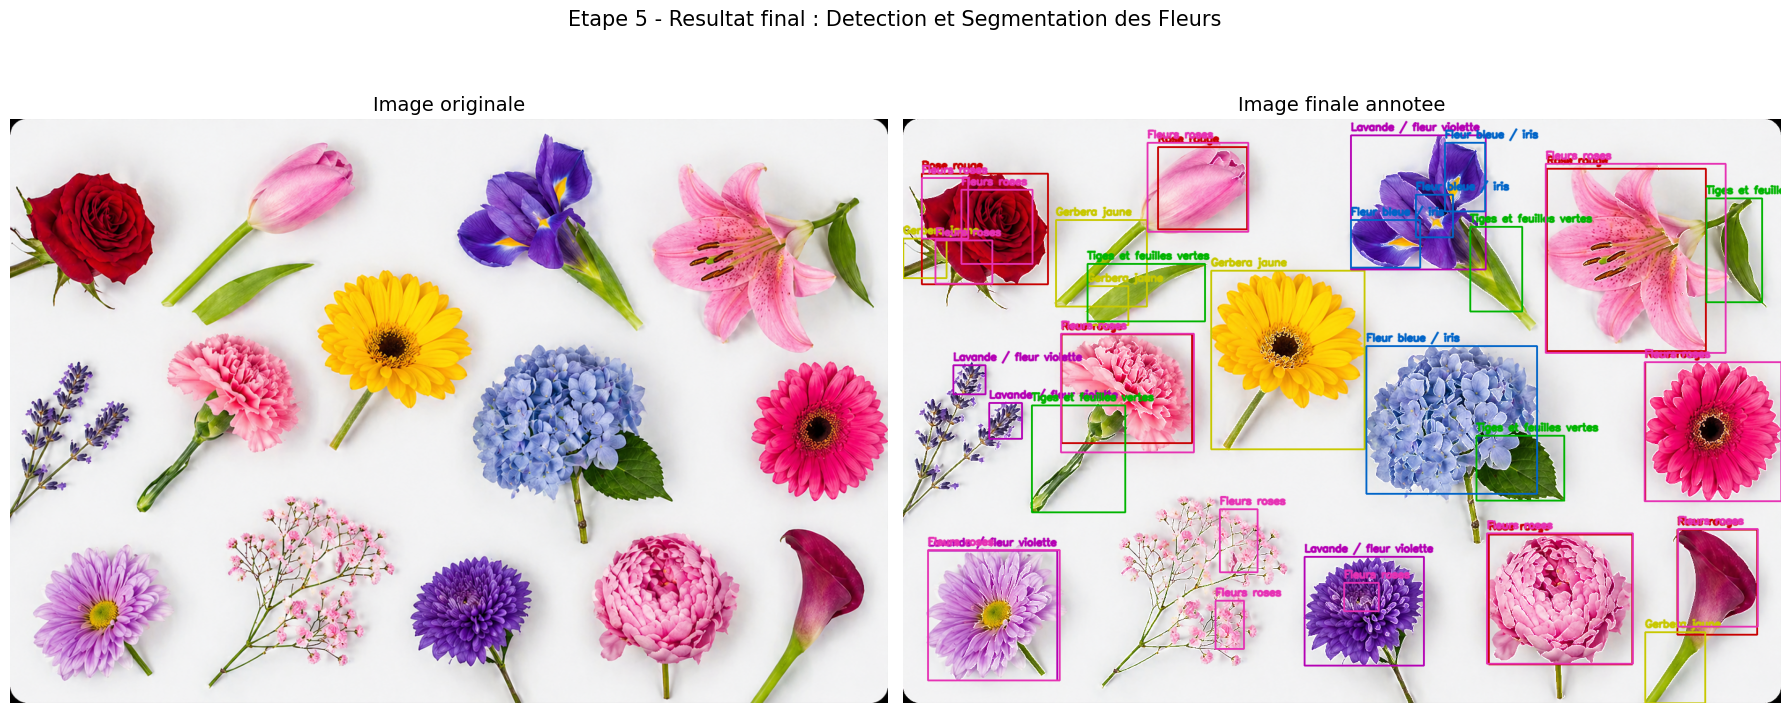

In [ ]:
# Affichage cote a cote : originale vs annotee
img_annotee_rgb = cv2.cvtColor(img_annotee, cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
axes[0].imshow(img_rgb)
axes[0].set_title('Image originale', fontsize=14)
axes[0].axis('off')
axes[1].imshow(img_annotee_rgb)
axes[1].set_title('Image finale annotee', fontsize=14)
axes[1].axis('off')

plt.suptitle('Etape 5 - Resultat final : Detection et Segmentation des Fleurs', fontsize=15)
plt.tight_layout()
plt.show()

